In [31]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)
from sklearn.model_selection import GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    make_scorer
)

from sklearn.dummy import DummyClassifier

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/raw/online_shoppers_intention.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
X = df.drop(columns=["Revenue"])
y = df["Revenue"].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12330, 17)
y shape: (12330,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (9864, 17)
Test set: (2466, 17)


In [5]:
def add_engineered_features(data):
    data = data.copy()

    data["TotalPages"] = (
        data["Administrative"]
        + data["Informational"]
        + data["ProductRelated"]
    )

    data["TotalDuration"] = (
        data["Administrative_Duration"]
        + data["Informational_Duration"]
        + data["ProductRelated_Duration"]
    )

    data["AvgDurationPerPage"] = np.where(
        data["TotalPages"] > 0,
        data["TotalDuration"] / data["TotalPages"],
        0
    )

    data["ProductPageShare"] = np.where(
        data["TotalPages"] > 0,
        data["ProductRelated"] / data["TotalPages"],
        0
    )

    data["ProductDurationShare"] = np.where(
        data["TotalDuration"] > 0,
        data["ProductRelated_Duration"] / data["TotalDuration"],
        0
    )

    return data

In [6]:
categorical_features = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType"
]

boolean_features = ["Weekend"]

numeric_features = [
    col for col in X_train.columns
    if col not in categorical_features + boolean_features
]

In [7]:
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        ("bool", "passthrough", boolean_features)
    ]
)

In [8]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        ("bool", "passthrough", boolean_features)
    ]
)


In [9]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [11]:
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),
    "f1": make_scorer(
        f1_score,
        zero_division=0
    ),
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [12]:
def summarize_cv(model_name, pipeline, X_data, y_data):

    scores = cross_validate(
        pipeline,
        X_data,
        y_data,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    row = {"Model": model_name}

    for metric in scoring:
        row[f"CV_{metric}_mean"] = scores[
            f"test_{metric}"
        ].mean()

        row[f"CV_{metric}_std"] = scores[
            f"test_{metric}"
        ].std()

    row["Train_F1_mean"] = scores["train_f1"].mean()
    row["Validation_F1_mean"] = scores["test_f1"].mean()

    return row, scores

In [13]:
from sklearn.dummy import DummyClassifier

dummy_pipeline = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", DummyClassifier(strategy="most_frequent"))
])

dummy_row, dummy_scores = summarize_cv(
    "Dummy - Most Frequent",
    dummy_pipeline,
    X_train,
    y_train
)

pd.DataFrame([dummy_row])

,Model,CV_accuracy_mean,CV_accuracy_std,CV_precision_mean,CV_precision_std,CV_recall_mean,CV_recall_std,CV_f1_mean,CV_f1_std,CV_roc_auc_mean,CV_roc_auc_std,CV_pr_auc_mean,CV_pr_auc_std,Train_F1_mean,Validation_F1_mean
0,Dummy - Most Frequent,0.845296,0.000197,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.154704,0.000197,0.0,0.0


Baseline comparison

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

In [21]:
lr_baseline = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

lr_baseline_row, lr_baseline_scores = summarize_cv(
    "Logistic Regression - Baseline",
    lr_baseline,
    X_train,
    y_train
)

In [22]:
knn_baseline = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", KNeighborsClassifier(
        n_neighbors=5
    ))
])

knn_baseline_row, knn_baseline_scores = summarize_cv(
    "KNN - Baseline",
    knn_baseline,
    X_train,
    y_train
)

In [23]:
dt_baseline = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

dt_baseline_row, dt_baseline_scores = summarize_cv(
    "Decision Tree - Baseline",
    dt_baseline,
    X_train,
    y_train
)

In [24]:
rf_baseline = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", RandomForestClassifier(
        random_state=42
    ))
])

rf_baseline_row, rf_baseline_scores = summarize_cv(
    "Random Forest - Baseline",
    rf_baseline,
    X_train,
    y_train
)

In [25]:
baseline_results = pd.DataFrame([
    dummy_row,
    lr_baseline_row,
    knn_baseline_row,
    dt_baseline_row,
    rf_baseline_row
])

baseline_results[
    [
        "Model",
        "CV_accuracy_mean",
        "CV_precision_mean",
        "CV_recall_mean",
        "CV_f1_mean",
        "CV_roc_auc_mean",
        "CV_pr_auc_mean"
    ]
].sort_values(
    "CV_pr_auc_mean",
    ascending=False
)

,Model,CV_accuracy_mean,CV_precision_mean,CV_recall_mean,CV_f1_mean,CV_roc_auc_mean,CV_pr_auc_mean
4,Random Forest - Baseline,0.899332,0.753262,0.518991,0.614473,0.923584,0.732332
1,Logistic Regression - Baseline,0.885443,0.746907,0.392519,0.514129,0.894383,0.645774
2,KNN - Baseline,0.872465,0.652465,0.378136,0.478082,0.799873,0.490911
3,Decision Tree - Baseline,0.863545,0.560248,0.553732,0.556357,0.736988,0.379235
0,Dummy - Most Frequent,0.845296,0.000000,0.000000,0.000000,0.500000,0.154704


Tuned model 

Logistic Regression Tuning

In [33]:
#lr tuning
lr_tune_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor_scaled
    ),
    (
        "model",
        LogisticRegression(
            max_iter=3000,
            solver="liblinear",
            random_state=42
        )
    )
])

In [35]:
lr_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
    "model__class_weight": [None, "balanced"]
}

In [37]:
lr_search = GridSearchCV(
    estimator=lr_tune_pipeline,
    param_grid=lr_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True
)

In [40]:
lr_search.fit(X_train, y_train)

print("Best CV PR-AUC:", lr_search.best_score_)
print("Best parameters:", lr_search.best_params_)

Best CV PR-AUC: 0.6664092050229934
Best parameters: {'model__C': 0.01, 'model__class_weight': 'balanced', 'model__penalty': 'l1'}


f:\Kawya\Y3S2\FDM\fdm project\BuySense\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
f:\Kawya\Y3S2\FDM\fdm project\BuySense\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [41]:
lr_search.fit(X_train, y_train)

f:\Kawya\Y3S2\FDM\fdm project\BuySense\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
f:\Kawya\Y3S2\FDM\fdm project\BuySense\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...liblinear'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__penalty': ['l1', 'l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for call

In [43]:
best_lr = lr_search.best_estimator_

lr_tuned_row, lr_tuned_scores = summarize_cv(
    "Logistic Regression - Tuned",
    best_lr,
    X_train,
    y_train
)

In [44]:
pd.DataFrame([lr_tuned_row])[
    [
        "Model",
        "CV_accuracy_mean",
        "CV_precision_mean",
        "CV_recall_mean",
        "CV_f1_mean",
        "CV_roc_auc_mean",
        "CV_pr_auc_mean"
    ]
]

,Model,CV_accuracy_mean,CV_precision_mean,CV_recall_mean,CV_f1_mean,CV_roc_auc_mean,CV_pr_auc_mean
0,Logistic Regression - Tuned,0.877231,0.580322,0.751645,0.654723,0.908397,0.666409


Decision tree tuning

In [45]:
dt_tune_pipeline = Pipeline([
    ("preprocessor", preprocessor_tree),
    (
        "model",
        DecisionTreeClassifier(
            random_state=42
        )
    )
])

In [46]:
dt_param_grid = {
    "model__max_depth": [3, 5, 7, 10, 15, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__class_weight": [None, "balanced"]
}

In [47]:
dt_search = GridSearchCV(
    estimator=dt_tune_pipeline,
    param_grid=dt_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=1,
    refit=True
)

In [48]:
dt_search.fit(X_train, y_train)

print("Best CV PR-AUC:", dt_search.best_score_)
print("Best parameters:", dt_search.best_params_)

Best CV PR-AUC: 0.7011880094819054
Best parameters: {'model__class_weight': None, 'model__max_depth': 5, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}


In [49]:
best_dt = dt_search.best_estimator_

In [50]:
dt_tuned_row, dt_tuned_scores = summarize_cv(
    "Decision Tree - Tuned",
    best_dt,
    X_train,
    y_train
)

In [51]:
pd.DataFrame([dt_tuned_row])[
    [
        "Model",
        "CV_accuracy_mean",
        "CV_precision_mean",
        "CV_recall_mean",
        "CV_f1_mean",
        "CV_roc_auc_mean",
        "CV_pr_auc_mean"
    ]
]

,Model,CV_accuracy_mean,CV_precision_mean,CV_recall_mean,CV_f1_mean,CV_roc_auc_mean,CV_pr_auc_mean
0,Decision Tree - Tuned,0.898724,0.706906,0.595013,0.64534,0.912919,0.701188


Random Forest Tuning

In [52]:
rf_for_tuning = Pipeline([
    ("preprocessor", preprocessor_tree),

    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

In [53]:
rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
    "model__class_weight": [None, "balanced"]
}

In [54]:
rf_search = GridSearchCV(
    estimator=rf_for_tuning,
    param_grid=rf_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=1,
    refit=True
)

In [55]:
rf_search.fit(X_train, y_train)

print("Best CV PR-AUC:", rf_search.best_score_)
print("Best parameters:", rf_search.best_params_)

Best CV PR-AUC: 0.7492873449970029
Best parameters: {'model__class_weight': None, 'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 300}


In [56]:
best_rf = rf_search.best_estimator_

In [57]:
rf_tuned_row, rf_tuned_scores = summarize_cv(
    "Random Forest - Tuned",
    best_rf,
    X_train,
    y_train
)

In [58]:
pd.DataFrame([rf_tuned_row])[
    [
        "Model",
        "CV_accuracy_mean",
        "CV_precision_mean",
        "CV_recall_mean",
        "CV_f1_mean",
        "CV_roc_auc_mean",
        "CV_pr_auc_mean"
    ]
]

,Model,CV_accuracy_mean,CV_precision_mean,CV_recall_mean,CV_f1_mean,CV_roc_auc_mean,CV_pr_auc_mean
0,Random Forest - Tuned,0.903387,0.778266,0.524888,0.626894,0.928209,0.749287


KNN Tuning

In [59]:
knn_tune_pipeline = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", KNeighborsClassifier())
])

In [60]:
knn_param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15, 21, 31],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

In [61]:
knn_search = GridSearchCV(
    estimator=knn_tune_pipeline,
    param_grid=knn_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=1,
    refit=True
)

In [62]:
knn_search.fit(X_train, y_train)

print("Best CV PR-AUC:", knn_search.best_score_)
print("Best parameters:", knn_search.best_params_)

Best CV PR-AUC: 0.6239669138956639
Best parameters: {'model__n_neighbors': 31, 'model__p': 2, 'model__weights': 'distance'}


In [63]:
best_knn = knn_search.best_estimator_

In [64]:
knn_tuned_row, knn_tuned_scores = summarize_cv(
    "KNN - Tuned",
    best_knn,
    X_train,
    y_train
)

In [65]:
pd.DataFrame([knn_tuned_row])[
    [
        "Model",
        "CV_accuracy_mean",
        "CV_precision_mean",
        "CV_recall_mean",
        "CV_f1_mean",
        "CV_roc_auc_mean",
        "CV_pr_auc_mean"
    ]
]

,Model,CV_accuracy_mean,CV_precision_mean,CV_recall_mean,CV_f1_mean,CV_roc_auc_mean,CV_pr_auc_mean
0,KNN - Tuned,0.880982,0.79548,0.311276,0.447,0.863895,0.623967


Tuned Model Comparison

In [66]:
tuned_results = pd.DataFrame([
    lr_tuned_row,
    knn_tuned_row,
    dt_tuned_row,
    rf_tuned_row
])

tuned_results[
    [
        "Model",
        "CV_accuracy_mean",
        "CV_precision_mean",
        "CV_recall_mean",
        "CV_f1_mean",
        "CV_roc_auc_mean",
        "CV_pr_auc_mean"
    ]
].sort_values(
    "CV_pr_auc_mean",
    ascending=False
)

,Model,CV_accuracy_mean,CV_precision_mean,CV_recall_mean,CV_f1_mean,CV_roc_auc_mean,CV_pr_auc_mean
3,Random Forest - Tuned,0.903387,0.778266,0.524888,0.626894,0.928209,0.749287
2,Decision Tree - Tuned,0.898724,0.706906,0.595013,0.645340,0.912919,0.701188
0,Logistic Regression - Tuned,0.877231,0.580322,0.751645,0.654723,0.908397,0.666409
1,KNN - Tuned,0.880982,0.795480,0.311276,0.447000,0.863895,0.623967


 Final Model Evaluation

Test-Set Evaluation

In [67]:
final_models = {
    "Logistic Regression - Tuned": best_lr,
    "KNN - Tuned": best_knn,
    "Decision Tree - Tuned": best_dt,
    "Random Forest - Tuned": best_rf
}

test_results = []

for model_name, model in final_models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    test_results.append({
        "Model": model_name,
        "Test_Accuracy": accuracy_score(y_test, y_pred),
        "Test_Precision": precision_score(y_test, y_pred, zero_division=0),
        "Test_Recall": recall_score(y_test, y_pred, zero_division=0),
        "Test_F1": f1_score(y_test, y_pred, zero_division=0),
        "Test_ROC_AUC": roc_auc_score(y_test, y_prob),
        "Test_PR_AUC": average_precision_score(y_test, y_prob)
    })

test_results_df = pd.DataFrame(test_results)

test_results_df

,Model,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC,Test_PR_AUC
0,Logistic Regression - Tuned,0.872263,0.568507,0.727749,0.638347,0.896519,0.629326
1,KNN - Tuned,0.874290,0.743243,0.287958,0.415094,0.848391,0.581001
2,Decision Tree - Tuned,0.899027,0.711111,0.586387,0.642755,0.917496,0.685826
3,Random Forest - Tuned,0.894972,0.753086,0.479058,0.585600,0.918186,0.728636


Final Model Confusion Matrix

In [68]:
final_model = best_rf

y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred_final)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["No Purchase", "Purchase"],
        zero_division=0
    )
)

Confusion Matrix:
[[2024   60]
 [ 199  183]]

Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.91      0.97      0.94      2084
    Purchase       0.75      0.48      0.59       382

    accuracy                           0.89      2466
   macro avg       0.83      0.73      0.76      2466
weighted avg       0.89      0.89      0.88      2466



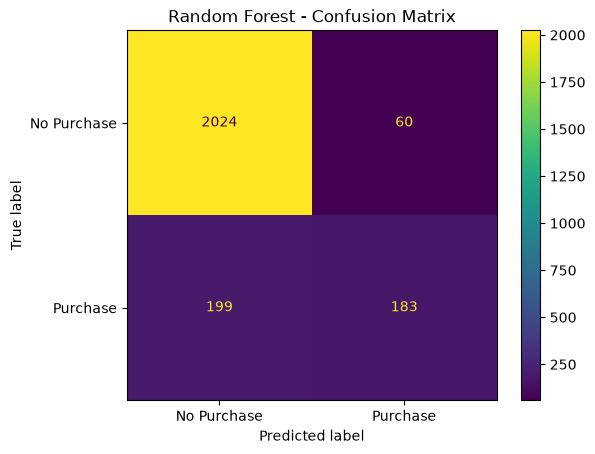

In [69]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Purchase", "Purchase"]
).plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

Train, Cross-Validation and Test Performance

In [70]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression - Tuned",
        "KNN - Tuned",
        "Decision Tree - Tuned",
        "Random Forest - Tuned"
    ],
    "CV_PR_AUC": [
        lr_tuned_row["CV_pr_auc_mean"],
        knn_tuned_row["CV_pr_auc_mean"],
        dt_tuned_row["CV_pr_auc_mean"],
        rf_tuned_row["CV_pr_auc_mean"]
    ],
    "Test_PR_AUC": [
        test_results_df.loc[
            test_results_df["Model"] == "Logistic Regression - Tuned",
            "Test_PR_AUC"
        ].iloc[0],
        test_results_df.loc[
            test_results_df["Model"] == "KNN - Tuned",
            "Test_PR_AUC"
        ].iloc[0],
        test_results_df.loc[
            test_results_df["Model"] == "Decision Tree - Tuned",
            "Test_PR_AUC"
        ].iloc[0],
        test_results_df.loc[
            test_results_df["Model"] == "Random Forest - Tuned",
            "Test_PR_AUC"
        ].iloc[0]
    ]
})

comparison["CV_Test_Difference"] = (
    comparison["CV_PR_AUC"] -
    comparison["Test_PR_AUC"]
)

comparison

,Model,CV_PR_AUC,Test_PR_AUC,CV_Test_Difference
0,Logistic Regression - Tuned,0.666409,0.629326,0.037083
1,KNN - Tuned,0.623967,0.581001,0.042967
2,Decision Tree - Tuned,0.701188,0.685826,0.015362
3,Random Forest - Tuned,0.749287,0.728636,0.020651


Final Results Summary

Final Test-Set Performance

In [72]:
final_results = test_results_df[
    [
        "Model",
        "Test_Accuracy",
        "Test_Precision",
        "Test_Recall",
        "Test_F1",
        "Test_ROC_AUC",
        "Test_PR_AUC"
    ]
].sort_values(
    "Test_PR_AUC",
    ascending=False
)

final_results

,Model,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC,Test_PR_AUC
3,Random Forest - Tuned,0.894972,0.753086,0.479058,0.585600,0.918186,0.728636
2,Decision Tree - Tuned,0.899027,0.711111,0.586387,0.642755,0.917496,0.685826
0,Logistic Regression - Tuned,0.872263,0.568507,0.727749,0.638347,0.896519,0.629326
1,KNN - Tuned,0.874290,0.743243,0.287958,0.415094,0.848391,0.581001


Test PR-AUC Comparison

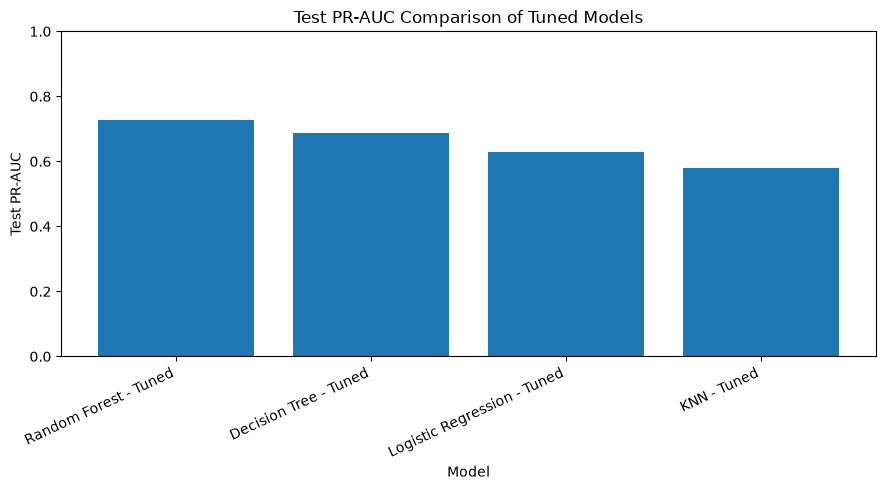

In [73]:
plt.figure(figsize=(9, 5))

plt.bar(
    final_results["Model"],
    final_results["Test_PR_AUC"]
)

plt.ylabel("Test PR-AUC")
plt.xlabel("Model")
plt.title("Test PR-AUC Comparison of Tuned Models")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

###  Interpretation

The tuned models showed different performance across the evaluation metrics. Among the four tuned models, Random Forest achieved the highest test PR-AUC, with a value of 0.7286. It also achieved a test ROC-AUC of 0.9182 and test precision of 0.7531.

Decision Tree achieved the highest test accuracy of 0.8990 and an F1-score of 0.6428. Logistic Regression achieved the highest test recall of 0.7277, indicating that it identified the largest proportion of actual purchasers among the evaluated models.

These results demonstrate that model performance depends on the evaluation metric. Therefore, accuracy alone is not sufficient for evaluating the BuySense purchase-prediction problem, particularly because the Purchase class is less common than the No Purchase class.